# CityBike Hub – Revenue analysis

Which item categories generate the most revenue? Revenue is calculated the same way as on the customer receipt:

**quantity × price per day × number of rental days** (same-day rentals count as one day), for all closed orders.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import rental

conn = rental.get_connection(':memory:')
rental.init_db(conn)   # fresh database with the sample data

## Revenue per category

`julianday()` converts ISO dates to numbers so SQLite can calculate the rental length. `MAX(1, …)` makes same-day rentals count as one day, matching `rental_days()` in Python.

In [2]:
query = """
SELECT
    c.name AS category,
    SUM(oi.quantity * i.price_per_day
        * MAX(1, CAST(julianday(ro.end_date) - julianday(ro.start_date) AS INTEGER))
    ) AS revenue_nok,
    COUNT(DISTINCT ro.order_id) AS orders
FROM OrderItem oi
JOIN Item        i  ON i.item_id      = oi.item_id
JOIN Category    c  ON c.category_id  = i.category_id
JOIN RentalOrder ro ON ro.order_id    = oi.order_id
WHERE ro.status = 'closed'
GROUP BY c.category_id
ORDER BY revenue_nok DESC;
"""
df = pd.read_sql_query(query, conn)
df

,category,revenue_nok,orders
0,vehicle,2250,5
1,safety equipment,360,3
2,accessories,220,2


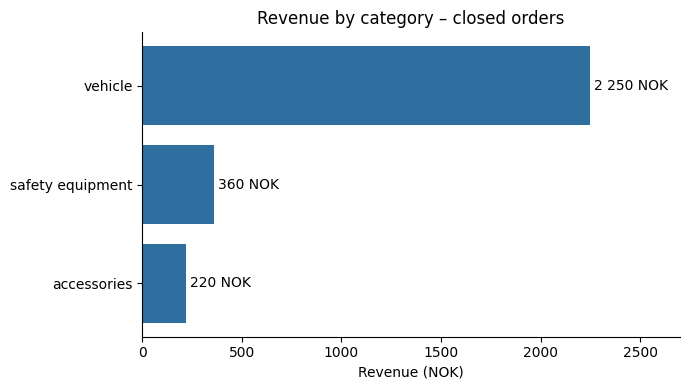

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(df["category"], df["revenue_nok"], color="#2f6f9f")
ax.invert_yaxis()
ax.set_xlabel("Revenue (NOK)")
ax.set_title("Revenue by category – closed orders")
for y, v in enumerate(df["revenue_nok"]):
    ax.text(v + 20, y, f"{v:,} NOK".replace(",", " "), va="center")
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(0, df["revenue_nok"].max() * 1.2)
plt.tight_layout()
plt.savefig("images/revenue_by_category.png", dpi=150)
plt.show()

## Why the number of days matters

The first version of this analysis summed `quantity × price_per_day` and ignored rental length. Comparing both shows how much revenue that would have understated:

In [4]:
naive = pd.read_sql_query("""
SELECT c.name AS category, SUM(oi.quantity * i.price_per_day) AS revenue_ignoring_days
FROM OrderItem oi
JOIN Item i ON i.item_id = oi.item_id
JOIN Category c ON c.category_id = i.category_id
JOIN RentalOrder ro ON ro.order_id = oi.order_id
WHERE ro.status = 'closed'
GROUP BY c.category_id
""", conn)
cmp = df.merge(naive, on="category")[["category", "revenue_ignoring_days", "revenue_nok"]]
cmp

,category,revenue_ignoring_days,revenue_nok
0,vehicle,850,2250
1,safety equipment,120,360
2,accessories,60,220


## Takeaways

- **Vehicles** (bikes and scooters) drive most of the revenue, as expected given their higher daily price.
- Ignoring rental length would understate revenue a lot, because multi-day rentals are where the money is.
- With a larger dataset, a natural next step would be utilisation per item (days rented ÷ days available) to see which items are worth buying more of.

In [5]:
conn.close()